# Loan Risk Analysis Notebook
This notebook performs **Loan Risk Analysis** using the `Loan_Risk_Data.csv` file.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Step 2: Load Data

In [2]:
df = pd.read_csv('Loan_Risk_Data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,L001,Male,Yes,0,Graduate,No,5000,2000,150,360,1,Urban,No
1,L002,Female,No,1,Graduate,Yes,3000,0,100,360,1,Rural,Yes
2,L003,Male,Yes,2,Not Graduate,No,4000,1500,120,360,0,Semiurban,No
3,L004,Male,No,0,Graduate,No,6000,0,200,360,1,Urban,Yes
4,L005,Female,Yes,3+,Graduate,No,3500,1200,130,360,0,Rural,No


## Step 3: Data Cleaning

In [3]:
print(df.isnull().sum())
print(df.duplicated().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
0


## Step 4: Exploratory Data Analysis (EDA)

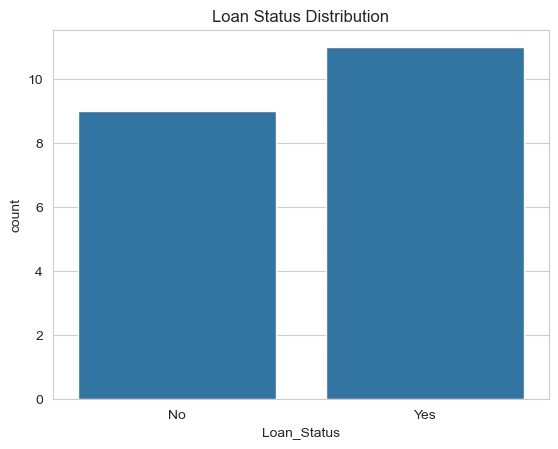

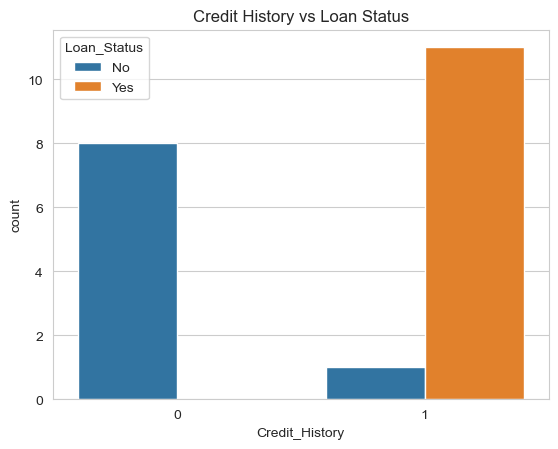

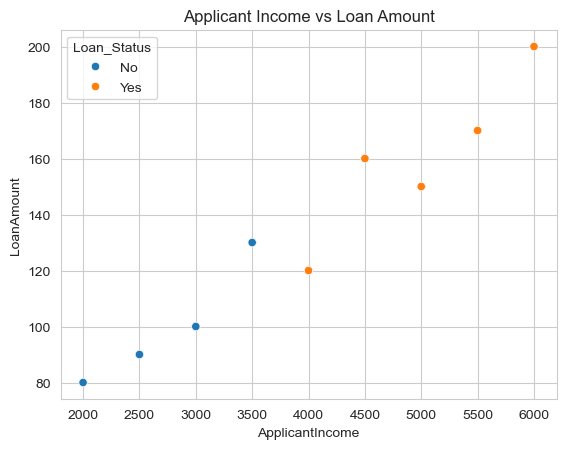

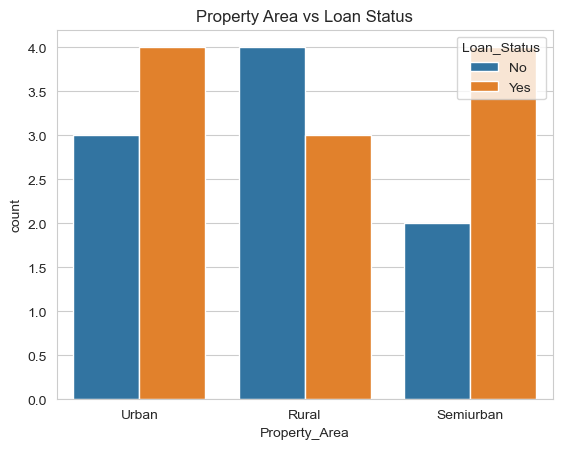

In [4]:
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.show()

sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=df)
plt.title('Applicant Income vs Loan Amount')
plt.show()

sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title('Property Area vs Loan Status')
plt.show()

## Step 5: Feature Engineering / Rule-based Risk Scoring

In [5]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

def risk_score(row):
    ratio = row['LoanAmount'] / row['TotalIncome']
    if row['Credit_History'] == 0 or ratio > 0.05:
        return 'High Risk'
    else:
        return 'Low Risk'

df['Risk'] = df.apply(risk_score, axis=1)
df[['Loan_ID','LoanAmount','TotalIncome','Credit_History','Risk']].head(10)

,Loan_ID,LoanAmount,TotalIncome,Credit_History,Risk
0,L001,150,7000,1,Low Risk
1,L002,100,3000,1,Low Risk
2,L003,120,5500,0,High Risk
3,L004,200,6000,1,Low Risk
4,L005,130,4700,0,High Risk
5,L006,90,3500,1,Low Risk
6,L007,160,6000,1,Low Risk
7,L008,80,2500,0,High Risk
8,L009,170,7500,1,Low Risk
9,L010,100,3000,0,High Risk


## Step 6: Risk Insights Visualization

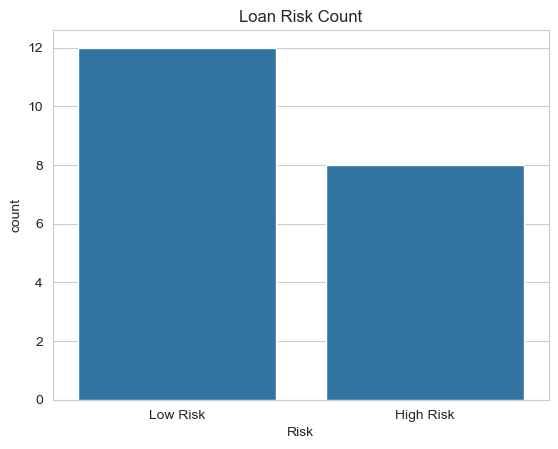

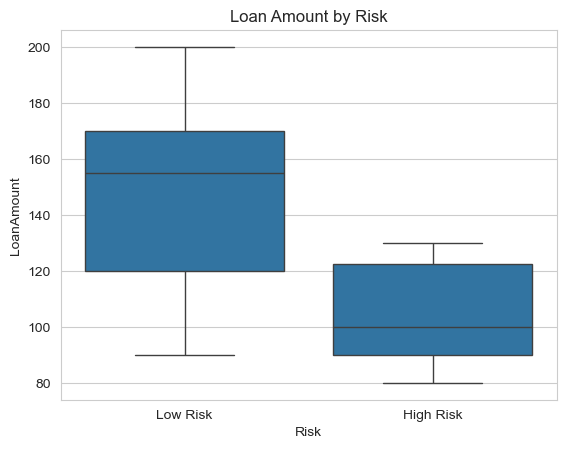

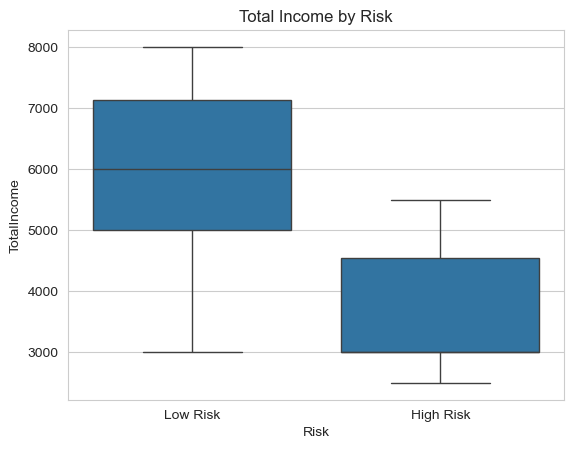

In [6]:
sns.countplot(x='Risk', data=df)
plt.title('Loan Risk Count')
plt.show()

sns.boxplot(x='Risk', y='LoanAmount', data=df)
plt.title('Loan Amount by Risk')
plt.show()

sns.boxplot(x='Risk', y='TotalIncome', data=df)
plt.title('Total Income by Risk')
plt.show()

## Step 7: Summary / Recommendations
- Most loans with bad credit history or high LoanAmount relative to income are flagged as High Risk.
- Banks can use this scoring for quick pre-screening.
- Visual insights help identify high-risk demographic or property areas.